# Exercício:

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [2]:
import numpy as np
mu, sigma = 5, 2
gene_expr_array = np.random.normal(mu, sigma, size=1000)
gene_expr_array

array([ 2.99598675,  2.15479878,  3.48196609,  4.1981066 ,  1.42581711,
        3.47460195,  5.24025648,  3.79422082,  6.78327059,  7.97176605,
        3.90607742,  5.35056463,  1.75694276,  4.21426655,  4.42472827,
        4.94219121,  4.18705484,  6.93994324,  6.29557664,  6.52593874,
        4.47825755,  3.59168737,  3.48309852,  5.044546  ,  4.80499111,
        5.89708703,  3.62801481,  3.19735646,  5.20688485,  4.57709347,
        6.25323963,  5.24219514,  4.5049666 ,  5.29496182,  1.98955763,
        4.15801205,  6.4075422 ,  5.0563824 ,  5.26182613,  7.70329391,
        5.04601712,  6.3891455 ,  6.62239304,  5.81870714,  4.65206305,
        3.6634448 ,  3.54528177,  5.02344727,  3.75883906,  4.93585403,
        4.20394941,  5.91968193,  3.90128021,  3.61877335,  4.44611155,
        4.11748097, 10.77727407,  7.53885576,  6.81097273,  2.5722867 ,
        2.88561414,  2.1173769 ,  5.25506396,  5.60171627,  5.23685201,
        5.12842756,  6.48628405,  2.66753877, -0.08378099,  6.69

## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [3]:
gene_dif_expr = np.random.randint(low=0, high=100, size=1000)

import pandas as pd

df = pd.DataFrame({"expr":gene_expr_array, "dif":gene_dif_expr})
df

,expr,dif
0,2.995987,52
1,2.154799,25
2,3.481966,56
3,4.198107,80
4,1.425817,88
...,...,...
995,6.051661,45
996,7.924584,64
997,5.744462,5
998,4.074338,89


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

R.: Pensei nos seguintes, para up  e down regulados, avaliar genes que tem baixa expressão, uma expressão mediana e expressão alta. Entender a dinamica da expressão genica em genes semelhantes pode ajudar a entender se existe alguma função diferente nesses genes em situações especificas, enquanto que entender a mudança de genes diferencialmente expressos podem auxiliar a explicar os diferentes desfechos dentro da linha experimental. 

In [4]:
df["reg"] = np.where(df["expr"] > df["expr"].mean(), 1, 0)
df
def categorizar_diferecialmente(value):
  if value < 33:
    return 'Pouco'
  elif value < 66:
    return 'Médio'
  else:
    return 'Muito'
df['dif_expr'] = df['dif'].apply(categorizar_diferecialmente)
df

,expr,dif,reg,dif_expr
0,2.995987,52,0,Médio
1,2.154799,25,0,Pouco
2,3.481966,56,0,Médio
3,4.198107,80,0,Muito
4,1.425817,88,0,Muito
...,...,...,...,...
995,6.051661,45,1,Médio
996,7.924584,64,1,Médio
997,5.744462,5,1,Pouco
998,4.074338,89,0,Muito


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [5]:
def return_freq_table(df: pd.DataFrame, column: str):
    freq_abs = df[column].value_counts().sort_index()
    freq_rel = df[column].value_counts(normalize=True).sort_index()
    freq = pd.DataFrame({
        "abso_simp": freq_abs,
        "relat_simp": freq_rel
    })
    return freq


In [6]:
freq_ordinal = return_freq_table(df, "reg")
print(freq_ordinal)

freq_nominal = return_freq_table(df, "dif_expr")
print(freq_nominal)


     abso_simp  relat_simp
reg                       
0          505       0.505
1          495       0.495
          abso_simp  relat_simp
dif_expr                       
Muito           354       0.354
Médio           322       0.322
Pouco           324       0.324


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

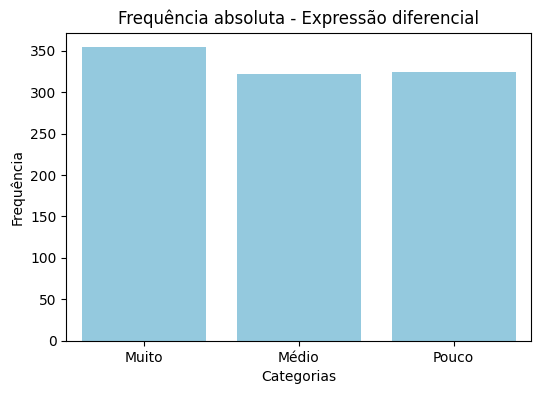

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x=freq_nominal.index, y=freq_nominal["abso_simp"], color="skyblue")
plt.title("Frequência absoluta - Expressão diferencial")
plt.ylabel("Frequência")
plt.xlabel("Categorias")
plt.show()


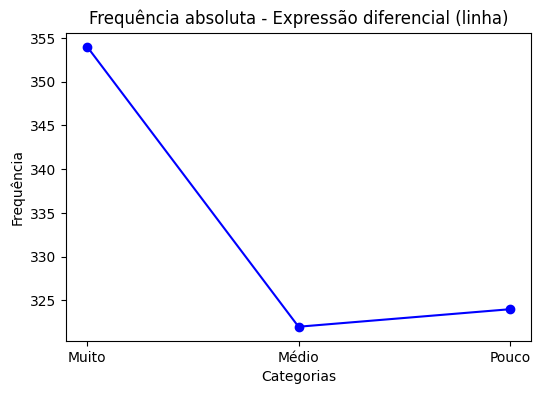

In [14]:
plt.figure(figsize=(6,4))
plt.plot(freq_nominal.index, freq_nominal["abso_simp"], marker="o", linestyle="-", color="blue")
plt.title("Frequência absoluta - Expressão diferencial (linha)")
plt.ylabel("Frequência")
plt.xlabel("Categorias")
plt.show()


### Número

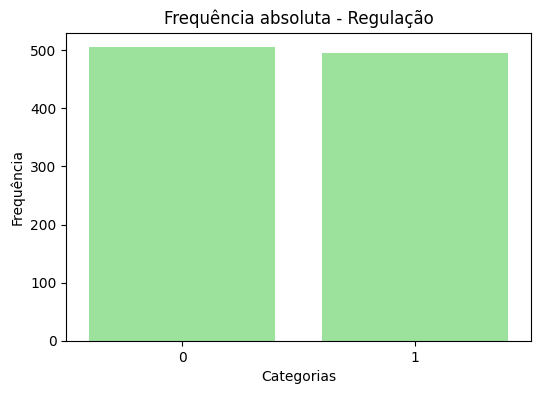

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(x=freq_ordinal.index, y=freq_ordinal["abso_simp"], color="lightgreen")
plt.title("Frequência absoluta - Regulação")
plt.ylabel("Frequência")
plt.xlabel("Categorias")
plt.show()


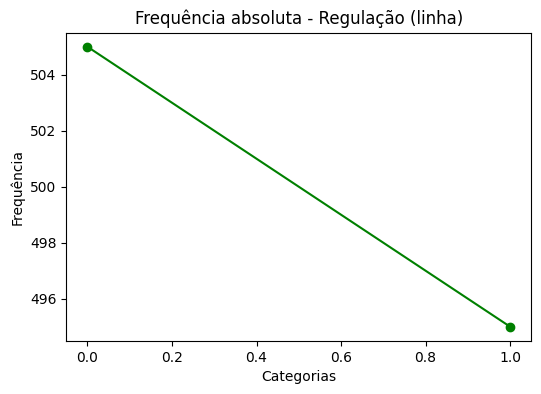

In [16]:
plt.figure(figsize=(6,4))
plt.plot(freq_ordinal.index, freq_ordinal["abso_simp"], marker="o", linestyle="-", color="green")
plt.title("Frequência absoluta - Regulação (linha)")
plt.ylabel("Frequência")
plt.xlabel("Categorias")
plt.show()


## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

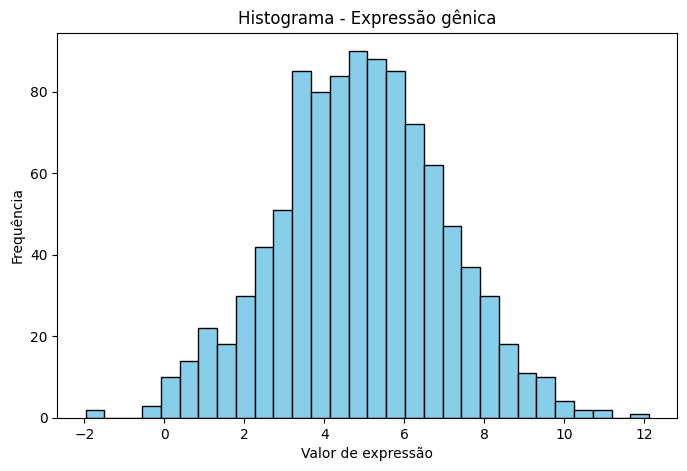

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["expr"], bins=30, color="skyblue", edgecolor="black")
plt.title("Histograma - Expressão gênica")
plt.xlabel("Valor de expressão")
plt.ylabel("Frequência")
plt.show()


## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

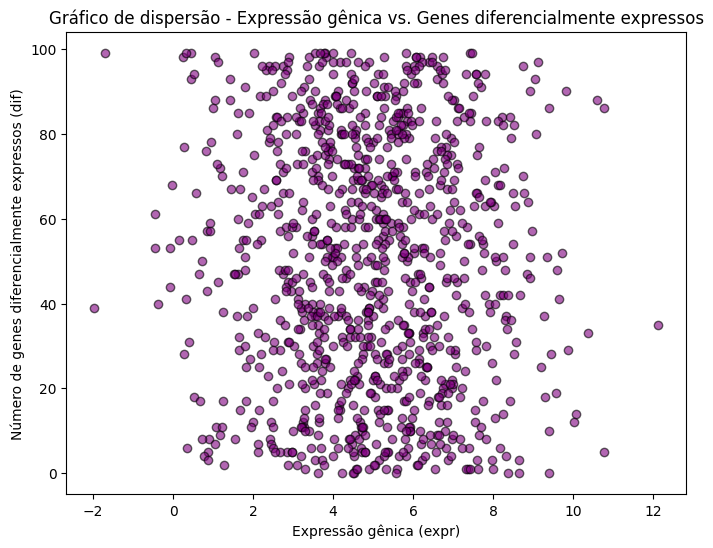

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(df["expr"], df["dif"], alpha=0.6, color="purple", edgecolor="black")
plt.title("Gráfico de dispersão - Expressão gênica vs. Genes diferencialmente expressos")
plt.xlabel("Expressão gênica (expr)")
plt.ylabel("Número de genes diferencialmente expressos (dif)")
plt.show()


## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

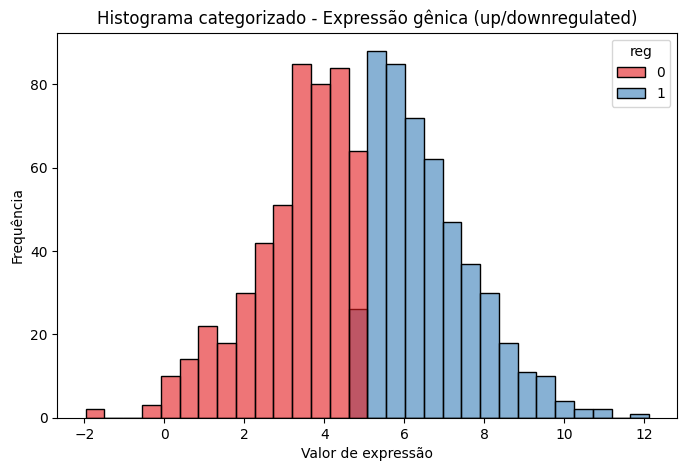

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="expr", hue="reg", bins=30, palette="Set1", alpha=0.6)
plt.title("Histograma categorizado - Expressão gênica (up/downregulated)")
plt.xlabel("Valor de expressão")
plt.ylabel("Frequência")
plt.show()


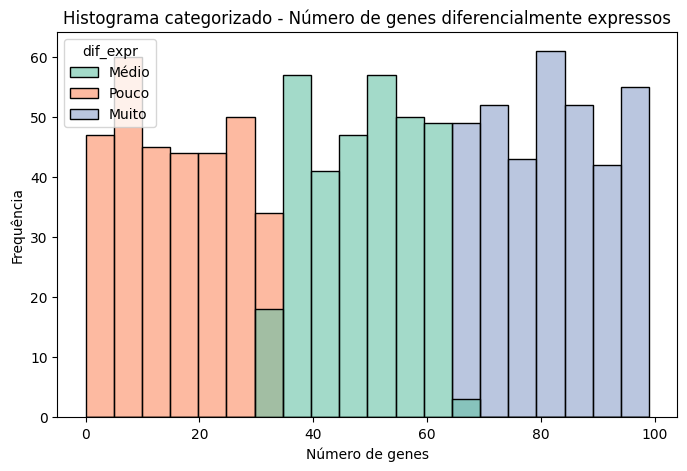

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="dif", hue="dif_expr", bins=20, palette="Set2", alpha=0.6)
plt.title("Histograma categorizado - Número de genes diferencialmente expressos")
plt.xlabel("Número de genes")
plt.ylabel("Frequência")
plt.show()


## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

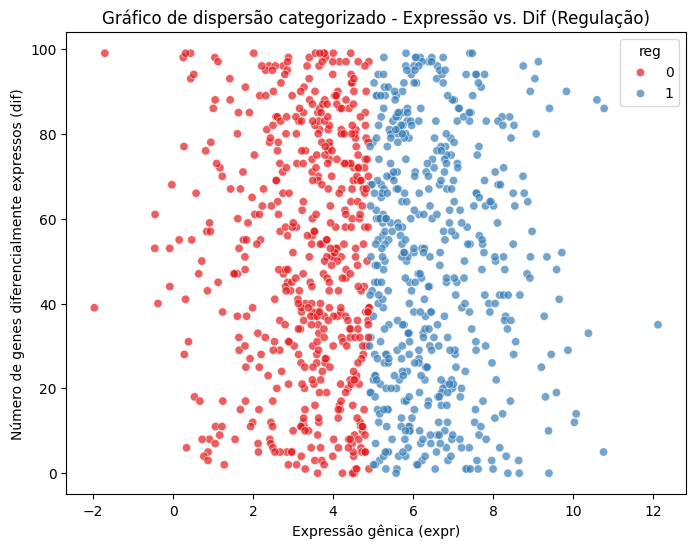

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="expr", y="dif", hue="reg", palette="Set1", alpha=0.7)
plt.title("Gráfico de dispersão categorizado - Expressão vs. Dif (Regulação)")
plt.xlabel("Expressão gênica (expr)")
plt.ylabel("Número de genes diferencialmente expressos (dif)")
plt.show()



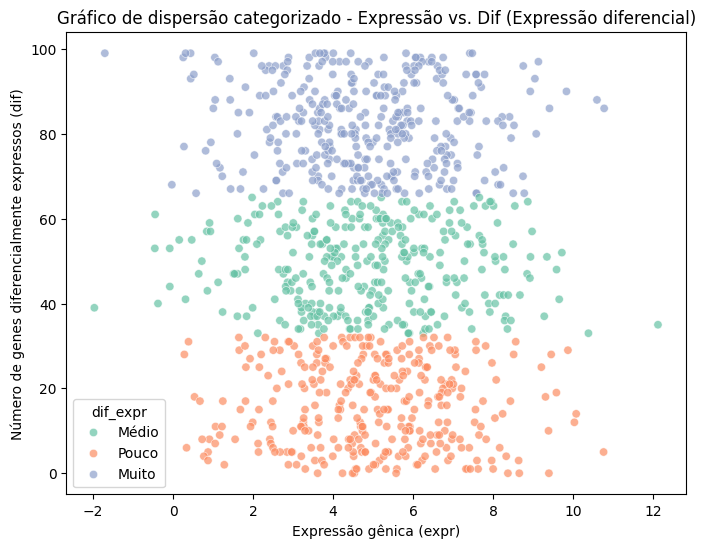

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="expr", y="dif", hue="dif_expr", palette="Set2", alpha=0.7)
plt.title("Gráfico de dispersão categorizado - Expressão vs. Dif (Expressão diferencial)")
plt.xlabel("Expressão gênica (expr)")
plt.ylabel("Número de genes diferencialmente expressos (dif)")
plt.show()


## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|discreta|
| % de células positivas|continua|
| Faixa de pH|ordinal|
| Valor de pH|continua|
| mol/L|continuas|
| UFC|discreta|
| D.O.|continua|
| Grupo Sanguíneo|nominal|
| Sorologia|nominal|